In [1]:
from utilities import * 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# BINS DISTRIBUTION PROBABILITIES 


In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CGAN_100b.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')

generator_params = {"hidden_dims": [512, 256, 256, 128]}
discriminator_params = {"hidden_dims": [512, 256, 256, 128, 64]}
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], output_dim=1, **discriminator_params)
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='cgan_100b_errors.csv')


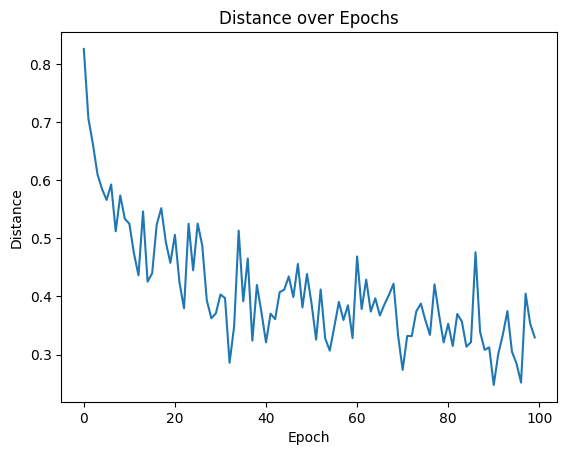

In [4]:
plot_learning_curve('generated_vs_true.csv')

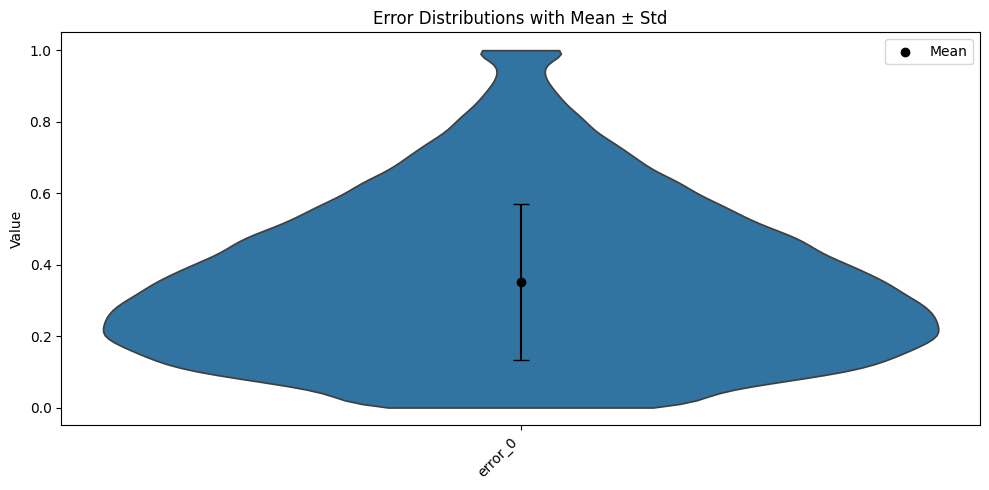

error_0    0.35127
dtype: float64 
 error_0    0.218632
dtype: float64 
             mean       std    median      skew  kurtosis  is_zero_test  \
error_0  0.35127  0.218632  0.318176  0.655748 -0.044113         False   

                               confidence_interval  
error_0  (0.34991502465302754, 0.3526252059783325)  


In [6]:
means, std, summary = analyze_error_distribution('./data/results/cgan_100b_errors.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [22]:
# data simulation 
# example

X0_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = (0.0, 0.0)#[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = (0.05, 0.6)#[0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [23]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0


0.298


,p_values
1,0.849433
2,0.959366
4,0.163074
5,0.261501
6,1.000000
...,...
991,0.066181
993,0.147062
994,0.643444
997,1.000000


In [26]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.006156041692067987

the js_distance is: 0.3430049362091364

the hellinger_distance is: 0.3067204701582432

the tv_distance is: 0.3078020846033994



In [19]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_100b.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_100b')
conditional_gan.load_models()



mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0


Bins loaded from models\bins\CGAN_100b.json
Loaded 101 bins
CGAN config loaded from ./models\CGAN_100b_config.json
Generator loaded from ./models\CGAN_100b_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_100b_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
0.3333333333333333


,p_values
2,1.000000
3,0.999991


In [20]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.5189563647613251), np.float64(0.53662516147538), np.float64(0.05496966365717054), np.float64(0.12063693390921344), np.float64(0.6691442188344264), np.float64(0.6134917645278953)]. The mean divergence is 0.41897068452756847


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [ ]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_v0.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='CWGAN_error_v0.csv')


In [ ]:
plot_learning_curve('wcgan_generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/CWGAN_v0.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [27]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=1)
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()



Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [28]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.412


,p_values
0,0.197153
1,0.999998
3,1.000000
5,0.095525
6,1.000000
...,...
989,0.417486
994,0.764545
995,0.466718
997,1.000000


In [30]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.00545012549837964

the js_distance is: 0.3050277923835073

the hellinger_distance is: 0.2711517301244348

the tv_distance is: 0.27250627491898194



In [9]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_v0.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_v0')
conditional_gan.load_models()


Bins loaded from models\bins\CWGAN_v0.json
Loaded 101 bins
CGAN config loaded from ./models\CWGAN_v0_config.json
Generator loaded from ./models\CWGAN_v0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_v0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [10]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
_, preds = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0


0.5


,p_values
0,1.000000
1,0.514957
2,1.000000


In [11]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.00018151219131523163), np.float64(0.14383606839277413), np.float64(0.03836084454393223), np.float64(0.24365957523197834), np.float64(0.9241381303515491), np.float64(0.23197149922807714)]. The mean divergence is 0.2636912716566044


In [ ]:
Xt

In [ ]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# FORGAN simple

In [ ]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_simple.json')

Bins saved to models\bins\forgan_simple.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":True}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_simple.csv')


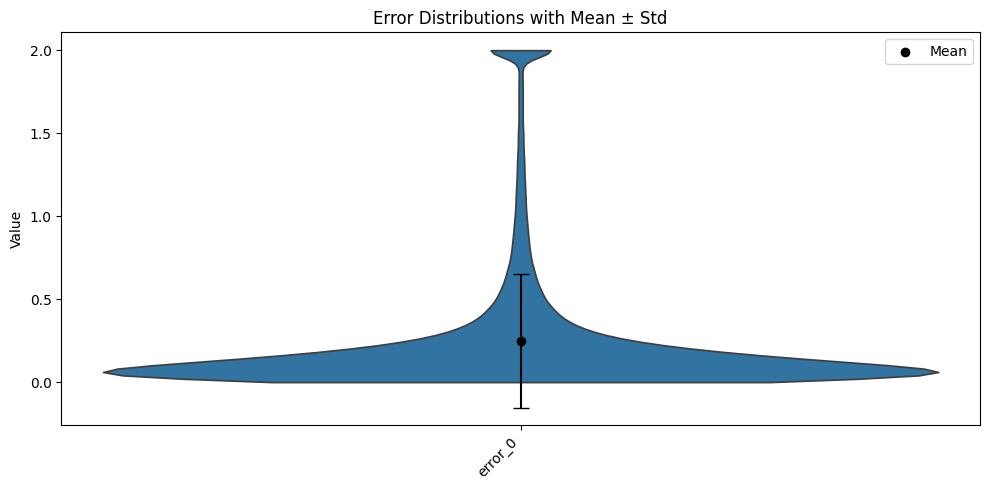

error_0    0.247726
dtype: float64 
 error_0    0.401025
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test  \
error_0  0.247726  0.401025  0.112539  3.155226  10.000242         False   

                                confidence_interval  
error_0  (0.24523996364248796, 0.25021109187599544)  


In [3]:
means, std, summary = analyze_error_distribution('./data/results/forgan_simple.csv')
print(means,'\n', std, '\n', summary)

## ks test

In [31]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))






Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.403


In [32]:
error_metrics = get_error_metrics(pdfs, generated)
for metric_name, metric in error_metrics.items():
    print(f'the {metric_name} is: {np.mean(metric)}\n')

the mae is: 0.005722757191302056

the js_distance is: 0.32778652178619344

the hellinger_distance is: 0.3000581576122027

the tv_distance is: 0.28613785956510274



In [49]:
# data simulation 
# example


X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()


Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [50]:

mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df



shape array (6, 1000)


,p_values
0,1.000000e+00
1,6.942820e-01
2,1.000000e+00
3,1.170598e-03
4,3.631426e-46
5,2.336083e-36


In [51]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.0), np.float64(0.17044913937191897), np.float64(0.016181990270845513), np.float64(0.32531171827873745), np.float64(0.837776004371311), np.float64(0.70919703980166)]. The mean divergence is 0.34315264868241213


In [ ]:
plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)

# FORGAN

In [ ]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_v3.json')

Bins saved to models\bins\forgan_v3.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [512, 256, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_v3.csv')


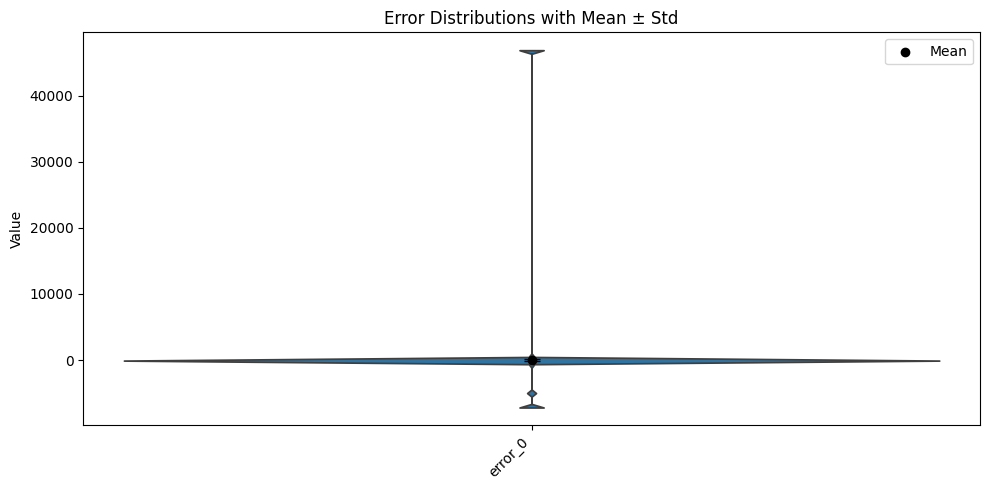

error_0    0.33918
dtype: float64 
 error_0    153.497078
dtype: float64 
             mean         std    median        skew      kurtosis  \
error_0  0.33918  153.497078 -0.026294  284.653331  86965.459361   

         is_zero_test                        confidence_interval  
error_0          True  (-0.6121983947104437, 1.2905591652713824)  


In [10]:
means, std, summary = analyze_error_distribution('./data/results/forgan_v3.csv')
print(means,'\n', std, '\n', summary)

## KS test 

In [33]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_v3.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins

conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()




mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)


p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))






Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
0.509


In [34]:
stats = get_error_metrics(true=pdfs, generated=generated)
for key, metric in stats.items():
    print(key, np.mean(metric))

mae 0.004373768602282822
js_distance 0.2600104304601003
hellinger_distance 0.2310411714400376
tv_distance 0.21868843011414105


In [57]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
mean_js

np.float64(0.2601222734613122)

### visual

In [58]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_v3.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_steps_ahead=1, P=paths[:, -1])
Xt = val.X_T
bins = val.bins


conditional_gan = MyCGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 64, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [59]:

mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = bins)



p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df



shape array (6, 1000)


,p_values
0,8.507710e-01
1,3.659532e-06
2,5.979232e-02
3,9.999036e-01
4,1.239234e-27
5,3.735969e-06


In [60]:
js_divergence = compute_js(generated, pdfs, is_log=False)
mean_js = np.mean(js_divergence)
print(f'js_divergence for each sample is {js_divergence}. The mean divergence is {mean_js}')

js_divergence for each sample is [np.float64(0.17661330112694035), np.float64(0.36243162503724086), np.float64(0.26016538933954814), np.float64(0.05294448426538006), np.float64(0.5069504314208595), np.float64(0.3145962895734002)]. The mean divergence is 0.2789502534605615


In [ ]:
plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)

# LSTM FORGAN

In [2]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_rnn.json')

Bins saved to models\bins\forgan_rnn.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {'rnn_layer':'gru'}
critic_params = {'use_layer_norm':True, 'rnn_layer':'gru'}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_rnn', z_noise_dim=64)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1],
                              hidden_dim_rnn=8, **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1],
                                  hidden_dim_rnn=8, **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_rnn.csv')
